In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
#from tensorflow.keras.applications.vgg16 import decode_predictions
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import joblib

loading raccoon image folder...
*completed raccoon folder* (739 images)
loading deer image folder...
*completed deer folder* (721 images)
loading squirrel image folder...
*completed squirrel folder* (798 images)


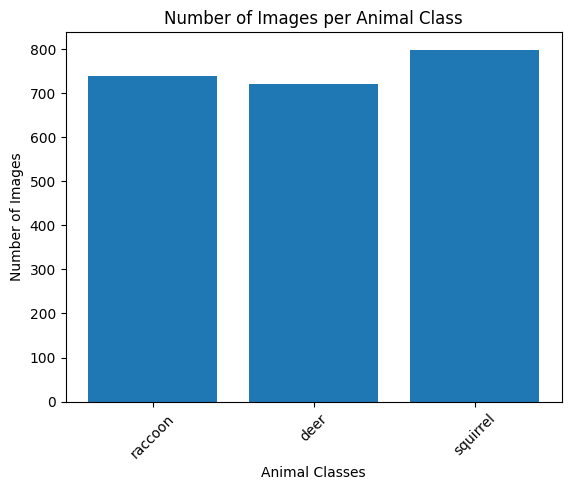

In [2]:
### Image Loading and Resizing, Data metrics
animals = ['raccoon','deer','squirrel']
img_data_arr = []
class_label_arr = []

datadir = "/Users/maneliiranmanesh/lila_training_data/images"  # updated: expanded bright/dim dataset + synthetic/real dark anchors
feature_shape = () # variable to print out the feature array's size
num_img_per_animal = [] # array holding number of images per folder
for i in animals:
    print(f"loading {i} image folder...")
    # combine base folder (bright+dim real photos) with _dark folder (synthetic darkened + real Pi dark anchors)
    img_dirs = [os.path.join(datadir, i), os.path.join(datadir, "_dark", i)]
    count_this_animal = 0
    for path_dir in img_dirs:
        if not os.path.isdir(path_dir):
            print(f"  warning: missing folder {path_dir}")
            continue
        for img_file in os.listdir(path_dir):
            img_path = os.path.join(path_dir, img_file)
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224), color_mode="rgb") # loads image, sizes it to 224x224, and forces it to be rgb (handles a couple of transparent images)
            img_array = tf.keras.preprocessing.image.img_to_array(img) # Turns the image into a numpy array
            img_data_arr.append(img_array) # appends single image array to total image array
            class_label_arr.append(animals.index(i)) # appends that image's class to total class array
            count_this_animal += 1
    num_img_per_animal.append(count_this_animal) # append number of images (bright+dim+dark combined) for this species
    print(f"*completed {i} folder* ({count_this_animal} images)")

# Convert to numpy
img_data = np.array(img_data_arr, dtype="float32")
class_labels = np.array(class_label_arr)


# Bar chart of Images per Animal Class
plt.bar(animals, num_img_per_animal)
plt.xlabel('Animal Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.title('Number of Images per Animal Class')
plt.show()


In [3]:
# using MobileNetV2 as a feature extractor and do include_top = False so it only returns 1280 size feature array
cnn_mobileV2 = MobileNetV2(weights="imagenet", input_shape = (224, 224, 3), include_top=False)
cnn_mobileV2.trainable = False  # freeze model so it doesn't use different weights for the train/test

# split train, test, and validation data before model training
X_train, X_temp, y_train, y_temp = train_test_split(img_data, class_labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [4]:
# Build Model: Data Augmentation to include random and realistic transformations to data, Uses MobileNetV2 for transfer learning
#              and preprocessing, and custom layers with reLU and softmax activation functions.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1), #layers.RandomZoom(0.1),
]) # Artificially increases the diversity and size of the training dataset by applying random, realistic transformations

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs) # Each training image gets randomly modified, each epoch gets slightly different version
x = preprocess_input(x) # Converts pixel values from [0, 255] → [-1, 1] because MobileNetV2 uses this format
x = cnn_mobileV2(x, training=False) # Detects edges, textures, shapes, patterns, returns feature map (7 x 7 x 1280 size)

x = layers.GlobalAveragePooling2D()(x) # Flattens to 1280 array
x = layers.Dense(128, activation='relu')(x) # learns patterns in this dataset regarding each animal class
x = layers.Dropout(0.3)(x) # randomly turns off 30% of neurons to prevent overfitting
output = layers.Dense(len(animals), activation='softmax')(x) # labels the output as probabilities for each class

model = models.Model(inputs=inputs, outputs=output)


In [5]:
# Compile and train the model with training data
model.compile(
    optimizer='adam', # adam (adaptive moment estimation) optimizer
    loss='sparse_categorical_crossentropy', # (for 0-7 labels)
    metrics=['accuracy'] 
)

model.fit(x=X_train, y=y_train, epochs=10, validation_data = (X_val,y_val), batch_size=16)

Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.6089 - loss: 0.8886 - val_accuracy: 0.7404 - val_loss: 0.6394
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.7228 - loss: 0.6304 - val_accuracy: 0.7788 - val_loss: 0.5723
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.7703 - loss: 0.5557 - val_accuracy: 0.7493 - val_loss: 0.5578
Epoch 4/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.7911 - loss: 0.5180 - val_accuracy: 0.7847 - val_loss: 0.5372
Epoch 5/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.7975 - loss: 0.4818 - val_accuracy: 0.7847 - val_loss: 0.5091
Epoch 6/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.8285 - loss: 0.4303 - val_accuracy: 0.8024 - val_loss: 0.4948
Epoch 7/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.8437 - loss: 0.3949 - val_accuracy: 0.8142 - val_loss: 0.4776
Epoch 8/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.8411 - loss: 0.4010 - val_accuracy: 0.7965 - v

In [6]:
# Retrains model but unfreezes top layers while keeping earlier layers frozen to finetune the model to the weights in the dataset
from sklearn.utils.class_weight import compute_class_weight

cnn_mobileV2.trainable = True

# Computed from the ACTUAL training set distribution instead of a hardcoded guess
# (the hardcoded {0: 1.0, 1: 2.5, 2: 1.0} was tuned for the old dataset's imbalance
# and doesn't reflect this expanded/light-bucketed dataset)
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight = {cls: w for cls, w in zip(np.unique(y_train), weights)}
print("Computed class weights (0=raccoon, 1=deer, 2=squirrel):", class_weight)

# Freeze lower layers, unfreeze top ones
for layer in cnn_mobileV2.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x=X_train, y=y_train, epochs=15, validation_data = (X_val,y_val), class_weight=class_weight)


Computed class weights (0=raccoon, 1=deer, 2=squirrel): {np.int64(0): np.float64(1.0533333333333332), np.int64(1): np.float64(1.036745406824147), np.int64(2): np.float64(0.9207459207459208)}
Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy: 0.7886 - loss: 0.5206 - val_accuracy: 0.8260 - val_loss: 0.4777
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 158ms/step - accuracy: 0.8051 - loss: 0.4568 - val_accuracy: 0.8319 - val_loss: 0.4760
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - accuracy: 0.8354 - loss: 0.4100 - val_accuracy: 0.8348 - val_loss: 0.4704
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.8354 - loss: 0.4050 - val_accuracy: 0.8348 - val_loss: 0.4691
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.8310 - loss: 0.3941 - val_accuracy: 0.8378 - val_loss: 0.4538
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - accuracy: 0.8532 - loss: 0.3751 - val_accuracy: 0.8378 - val_loss: 0.4471
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.8407 - loss: 0.4376
Model R-squared score on test data: [0.43757566809654236, 0.8407079577445984]
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step
Test set's F1 Score: 0.8406287763587225
Test set's Accuracy: 0.8407079646017699


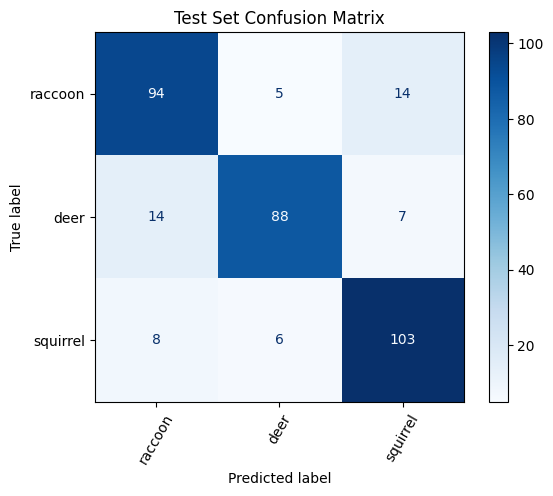

In [7]:
score = model.evaluate(X_test, y_test)
print(f"Model R-squared score on test data: {score}")

# Make predictions on the test data
predictions = model.predict(X_test)
y_pred = np.argmax(predictions, axis=1)
print("Test set's F1 Score:", f1_score(y_test, y_pred, average="macro"))
print("Test set's Accuracy:", accuracy_score(y_test, y_pred))

confusion_test = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_test, display_labels=animals)
disp.plot(cmap="Blues", xticks_rotation=60)
plt.title("Test Set Confusion Matrix")
plt.show()

In [9]:
### Testing on real-world frozen test set
img_data_arr_TEST = []

datadir = "/Users/maneliiranmanesh/Desktop/School - Rutgers/Capstone/frozen_test_set"
files = sorted([f for f in os.listdir(datadir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

for img_file in files:
    img_path = os.path.join(datadir, img_file)
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224), color_mode="rgb")
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_data_arr_TEST.append(img_array)

img_data = np.array(img_data_arr_TEST, dtype="float32")

label_map = {'raccoon': 0, 'deer': 1, 'squirrel': 2}
class_labels = np.array([label_map[f.split('_')[0]] for f in files])

predictions = model.predict(img_data)
y_predict_TEST = np.argmax(predictions, axis=1)
print(list(zip(files, y_predict_TEST)))  # lets you sanity-check which file got which prediction
print("New Test set's F1 Score:", f1_score(class_labels, y_predict_TEST, average="macro"))
print("New Test set's Accuracy:", accuracy_score(class_labels, y_predict_TEST))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[('deer_1.jpg', np.int64(1)), ('deer_2.jpg', np.int64(1)), ('raccoon_1.jpg', np.int64(0)), ('raccoon_2.jpg', np.int64(0)), ('squirrel_1.jpeg', np.int64(2)), ('squirrel_2.jpg', np.int64(2))]
New Test set's F1 Score: 1.0
New Test set's Accuracy: 1.0


In [10]:
### Sending Model via scp over to Raspberry PI

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("gardenPal_animal_model.tflite", "wb") as f:
    f.write(tflite_model)


INFO:tensorflow:Assets written to: /var/folders/cg/qxy9w10j2vs8jh0w0n8q740m0000gn/T/tmpjxp8x668/assets


INFO:tensorflow:Assets written to: /var/folders/cg/qxy9w10j2vs8jh0w0n8q740m0000gn/T/tmpjxp8x668/assets


Saved artifact at '/var/folders/cg/qxy9w10j2vs8jh0w0n8q740m0000gn/T/tmpjxp8x668'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  6094379280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6094382352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6094381584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6094383888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6094382736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6094384464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6094382928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6094385040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6094384656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6094382544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6094383312: Tens

W0000 00:00:1785723411.098827  235805 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1785723411.098837  235805 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1785723411.099012  235805 reader.cc:83] Reading SavedModel from: /var/folders/cg/qxy9w10j2vs8jh0w0n8q740m0000gn/T/tmpjxp8x668
I0000 00:00:1785723411.103331  235805 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1785723411.103335  235805 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/cg/qxy9w10j2vs8jh0w0n8q740m0000gn/T/tmpjxp8x668
I0000 00:00:1785723411.146560  235805 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1785723411.154795  235805 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1785723411.439203  235805 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/cg/qxy9w10j2vs8jh0w0n8q740m0000gn/T/tmpjxp8x668
I0000 00:00:1785723411.522542  235805 lo

In [11]:
#import cv2
#import numpy as np

# Load model
#net = cv2.dnn.readNetFromCaffe(
    #"MobileNetSSD_deploy.prototxt",
    #"MobileNetSSD_deploy.caffemodel"
#)

# Class labels MobileNet was trained on
#CLASSES = ["background", "aeroplane", "bicycle", "bird", "boat",
           #"bottle", "bus", "car", "cat", "chair", "cow", "diningtable",
           #"dog", "horse", "motorbike", "person", "pottedplant",
           #"sheep", "sofa", "train", "tvmonitor"]

#def detect_human(image_path):
    #frame = cv2.imread(image_path)

    #if frame is None:
        #print("Error: Could not load image")
        #return

    #h, w = frame.shape[:2]

    #blob = cv2.dnn.blobFromImage(frame, 0.007843, (300, 300), 127.5)
    #net.setInput(blob)
    #detections = net.forward()

    #for i in range(detections.shape[2]):
        #confidence = detections[0, 0, i, 2]

        #if confidence > 0.5:
            #idx = int(detections[0, 0, i, 1])

            #if CLASSES[idx] == "person":
                #return True  # Human found

    #return False  # No human

#datadir_human = r"C:\Users\Using Janani\Downloads\human1.jpg"
#datadir_dog = r"C:\Users\Using Janani\Downloads\gardenPal_testset\img1_dog.jpg"
#print(detect_human(datadir_human))
#print(detect_human(datadir_dog))
#import os; print(os.getcwd())
#import sys
#print(sys.executable)